### **Stage 4: Typological Analysis**

Clustering on **income deprivation + 3 environmental variables** only.

**Health burden (HlthCIF)** is reserved as an **external validation** indicator.

In [ ]:
# Imports

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.decomposition import PCA
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from itertools import permutations
import scikit_posthocs as sp

np.random.seed(42)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white'
})

#### **· Variable preparation and multicollinearity check**

In [ ]:
# Load data and prepare variables

gdf = gpd.read_file('GLA_Master.shp')

# Clean columns (consistent with ESDA notebook)
gdf['IncRate_2020'] = gdf['IncRate'].str.replace('%', '').astype(float)
gdf['IncRate_2016'] = gdf['IncRate_1'] * 100
gdf['VDL_2020']     = gdf['VDL_Ratio2']
gdf['VDL_2016']     = gdf['VDL_Ratio1']
gdf['NoGreen']      = 1 - gdf['PAN_GreenR']
gdf['Inc_Change']   = gdf['IncRate_2020'] - gdf['IncRate_2016']

# 4 clustering variables (income + 3 environmental)
# Health (HlthCIF) is held out for external validation
# All oriented so HIGHER = WORSE
cluster_cols   = ['IncRate_2020', 'NO2_2020', 'VDL_2020', 'NoGreen']
cluster_labels = ['Income deprivation', 'NO\u2082', 'VDL', 'Lack of green space']

# NaN check
print('NaN check:')
for col in cluster_cols:
    n_miss = gdf[col].isna().sum()
    if n_miss > 0:
        med = gdf[col].median()
        print(f'  WARNING: {col} has {n_miss} NaN(s) - filling with median ({med:.2f})')
        gdf[col] = gdf[col].fillna(med)
    else:
        print(f'  OK: {col}')

n_miss_h = gdf['HlthCIF'].isna().sum()
if n_miss_h > 0:
    gdf['HlthCIF'] = gdf['HlthCIF'].fillna(gdf['HlthCIF'].median())
    print(f'  WARNING: HlthCIF has {n_miss_h} NaN(s) - filled with median')
else:
    print('  OK: HlthCIF (validation variable)')

X_raw = gdf[cluster_cols].values
print()
print(f'Clustering on {len(cluster_cols)} variables, {X_raw.shape[0]} zones')
print('Validation variable: HlthCIF (Health burden)')
print()
print('Variable ranges:')
for col in cluster_cols + ['HlthCIF']:
    print(f'  {col}: {gdf[col].min():.3f} to {gdf[col].max():.3f}')

NaN check:
  OK: IncRate_2020
  OK: NO2_2020
  OK: VDL_2020
  OK: NoGreen
  OK: HlthCIF (validation variable)

Clustering on 4 variables, 746 zones
Validation variable: HlthCIF (Health burden)

Variable ranges:
  IncRate_2020: 0.000 to 59.000
  NO2_2020: 7.273 to 26.693
  VDL_2020: 0.000 to 1.000
  NoGreen: 0.285 to 0.995
  HlthCIF: 0.000 to 370.000


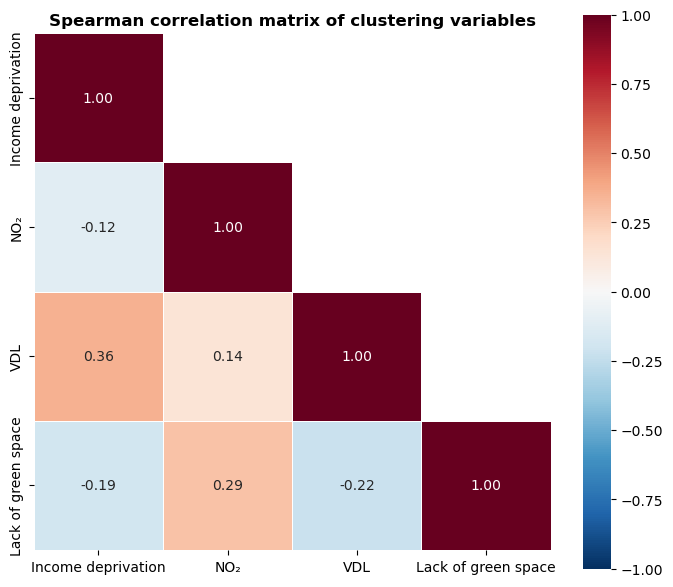


Correlation with validation variable (HlthCIF):
  Income deprivation     r = +0.961  (p = 0.00e+00)
  NO₂                    r = -0.130  (p = 3.57e-04)
  VDL                    r = +0.374  (p = 3.60e-26)
  Lack of green space    r = -0.200  (p = 3.44e-08)


In [ ]:
# Correlation matrix of clustering variables

corr = gdf[cluster_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, mask=mask,
            xticklabels=cluster_labels, yticklabels=cluster_labels, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Spearman correlation matrix of clustering variables')
plt.tight_layout()
plt.show()

# Correlation with the validation variable
print()
print('Correlation with validation variable (HlthCIF):')
for col, lab in zip(cluster_cols, cluster_labels):
    r, p = stats.spearmanr(gdf[col], gdf['HlthCIF'])
    print(f'  {lab:<22} r = {r:+.3f}  (p = {p:.2e})')

#### **· Standardisation**

In [ ]:
# Z-score standardisation

scaler = StandardScaler()
X_z = scaler.fit_transform(X_raw)

print('Z-score standardised ranges:')
for i, col in enumerate(cluster_cols):
    v = X_z[:, i]
    print(f'  {col}: {v.min():.3f} to {v.max():.3f}, mean={v.mean():.3f}, std={v.std():.3f}')

Z-score standardised ranges:
  IncRate_2020: -1.621 to 3.211, mean=-0.000, std=1.000
  NO2_2020: -1.882 to 3.672, mean=-0.000, std=1.000
  VDL_2020: -0.695 to 3.313, mean=0.000, std=1.000
  NoGreen: -4.752 to 1.835, mean=0.000, std=1.000


#### **· Optimal *K* Selection**

c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to 

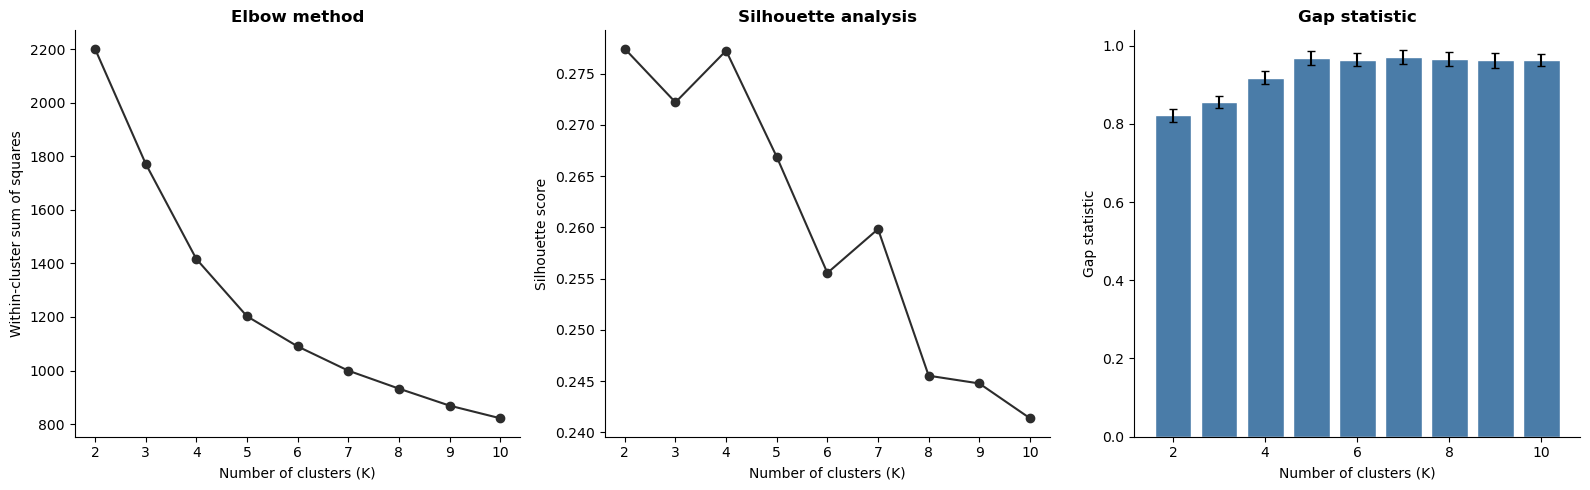


K           WCSS   Silhouette        Gap
----------------------------------------
2         2201.9       0.2774     0.8216
3         1772.5       0.2722     0.8558
4         1416.8       0.2772     0.9181
5         1202.7       0.2669     0.9691
6         1090.2       0.2556     0.9644
7          999.5       0.2598     0.9713
8          932.4       0.2455     0.9656
9          868.9       0.2448     0.9623
10         821.7       0.2414     0.9628
Gap statistic optimal K = 5
Silhouette peak at K = 2


In [ ]:
# Determine optimal K (Elbow + Silhouette + Gap Statistic)

K_range = range(2, 11)

# Elbow (WCSS)
wcss = []
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=50, random_state=42)
    km.fit(X_z)
    wcss.append(km.inertia_)

# Silhouette
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=50, random_state=42)
    labels = km.fit_predict(X_z)
    sil_scores.append(silhouette_score(X_z, labels))

# Gap statistic
def gap_statistic(X, K_range, n_refs=50):
    gaps, s_k = [], []
    for k in K_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=50, random_state=42)
        km.fit(X)
        obs = np.log(km.inertia_)
        refs = []
        for _ in range(n_refs):
            X_ref = np.random.uniform(X.min(axis=0), X.max(axis=0), size=X.shape)
            km_r = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
            km_r.fit(X_ref)
            refs.append(np.log(km_r.inertia_))
        gaps.append(np.mean(refs) - obs)
        s_k.append(np.std(refs) * np.sqrt(1 + 1/n_refs))
    return gaps, s_k

gaps, s_k = gap_statistic(X_z, K_range)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(list(K_range), wcss, 'o-', color='#2C2C2C', markersize=6)
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Within-cluster sum of squares')
axes[0].set_title('Elbow method')
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(list(K_range), sil_scores, 'o-', color='#2C2C2C', markersize=6)
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette analysis')
axes[1].spines[['top', 'right']].set_visible(False)

axes[2].bar(list(K_range), gaps, yerr=s_k, color='#4A7CA8', edgecolor='white', capsize=3)
axes[2].set_xlabel('Number of clusters (K)')
axes[2].set_ylabel('Gap statistic')
axes[2].set_title('Gap statistic')
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Summary table
print()
header = f'{"K":<5} {"WCSS":>10} {"Silhouette":>12} {"Gap":>10}'
print(header)
print('-' * 40)
for i, k in enumerate(K_range):
    print(f'{k:<5} {wcss[i]:>10.1f} {sil_scores[i]:>12.4f} {gaps[i]:>10.4f}')

# Tibshirani rule
for i in range(len(gaps) - 1):
    if gaps[i] >= gaps[i+1] - s_k[i+1]:
        print(f'Gap statistic optimal K = {list(K_range)[i]}')
        break

print(f'Silhouette peak at K = {list(K_range)[np.argmax(sil_scores)]}')

Reason for choosing *K*=5?

#### **· K-means clustering & PCA dimensionality reduction**

In [ ]:
# K-Means clustering

K = 5

km_final = KMeans(n_clusters=K, init='k-means++', n_init=50, random_state=42)
gdf['Cluster'] = km_final.fit_predict(X_z)

print(f'K-means clustering (K={K})')
sil = silhouette_score(X_z, gdf['Cluster'])
print(f'Silhouette score: {sil:.4f}')
print()
print('Cluster sizes:')
print(gdf['Cluster'].value_counts().sort_index())

c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


K-means clustering (K=5)
Silhouette score: 0.2669

Cluster sizes:
Cluster
0    172
1    114
2    117
3    226
4    117
Name: count, dtype: int64


In [ ]:
# PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_z)

print('=' * 60)
print('PCA RESULTS')
print('=' * 60)
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'PC{i+1}: {var:.3f}')
print()
total_var = pca.explained_variance_ratio_.sum()
print(f'Total variance explained = {total_var:.3f}')

# Variable loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=cluster_labels
)
print()
print('Variable loadings:')
display(loadings.round(3))

PCA RESULTS
PC1: 0.380
PC2: 0.302

Total variance explained = 0.682

Variable loadings:


,PC1,PC2
Income deprivation,0.582,0.297
NO₂,-0.404,0.644
VDL,0.441,0.619
Lack of green space,-0.551,0.338


#### **· Descriptive naming based on profile**

In [ ]:
# Cluster naming and profiling
# Mean z-scores per cluster
profile_z = pd.DataFrame(X_z, columns=cluster_labels)
profile_z['Cluster'] = gdf['Cluster'].values
means_z = profile_z.groupby('Cluster').mean()

# Disadvantage score
means_z['Disadvantage'] = means_z.mean(axis=1)
sorted_clusters = means_z['Disadvantage'].sort_values(ascending=False)

# Descriptive naming based on actual z-score profiles
# Cluster 1: Inc=0.97, VDL=1.88  → high income dep + extreme vacant and derelict land
# Cluster 2: Inc=-0.49, NO₂=1.78, Green=0.58 → low income but high pollution
# Cluster 0: Inc=0.85, low environmental stress → income-driven deprivation
# Cluster 3: Inc=-0.88, all low → generally low deprivation
# Cluster 4: Inc=-0.01, Green=-1.55 → moderate income, greenest areas
cluster_names = {
    1: 'Concentrated deprivation',
    2: 'Environmental stress',
    0: 'Socioeconomic disadvantage',
    3: 'Low deprivation',
    4: 'Green suburban',
}

gdf['Type'] = gdf['Cluster'].map(cluster_names)

# Colour scheme
TYPE_COLORS = {
    'Concentrated deprivation':   '#d73027',
    'Socioeconomic disadvantage': '#fc8d59',
    'Environmental stress':       '#fee090',
    'Green suburban':             '#91bfdb',
    'Low deprivation':            '#4575b4',
}

# Order: worst to best by disadvantage score
type_order = [cluster_names[c] for c in sorted_clusters.index]

print('=== Cluster names (profile-based) ===')
print()
for cid in sorted_clusters.index:
    name = cluster_names[cid]
    score = means_z.loc[cid, 'Disadvantage']
    n = (gdf["Cluster"] == cid).sum()
    print(f'  Cluster {cid} -> {name} (n={n}, disadvantage={score:+.3f})')

# Raw-value profiles
profile_raw = gdf.groupby('Type')[cluster_cols].mean()
profile_raw.columns = cluster_labels
print()
print('=== Cluster profiles (original values, clustering variables) ===')
print()
display(profile_raw.round(2))

# Health preview
print()
print('=== Health burden by type (HlthCIF - NOT used in clustering) ===')
print()
for t in type_order:
    s = gdf[gdf['Type'] == t]['HlthCIF']
    print(f'  {t:<35} mean={s.mean():.1f}  median={s.median():.1f}')

=== Cluster names (profile-based) ===

  Cluster 1 -> Concentrated deprivation (n=114, disadvantage=+0.600)
  Cluster 2 -> Environmental stress (n=117, disadvantage=+0.462)
  Cluster 0 -> Socioeconomic disadvantage (n=172, disadvantage=+0.154)
  Cluster 3 -> Low deprivation (n=226, disadvantage=-0.333)
  Cluster 4 -> Green suburban (n=117, disadvantage=-0.631)

=== Cluster profiles (original values, clustering variables) ===



,Income deprivation,NO₂,VDL,Lack of green space
Type,,,,
Concentrated deprivation,31.64,13.42,0.64,0.76
Environmental stress,13.78,20.07,0.17,0.86
Green suburban,19.72,11.63,0.09,0.63
Low deprivation,9.05,12.59,0.04,0.84
Socioeconomic disadvantage,30.20,13.09,0.09,0.83



=== Health burden by type (HlthCIF - NOT used in clustering) ===

  Concentrated deprivation            mean=217.2  median=225.0
  Environmental stress                mean=114.7  median=110.0
  Socioeconomic disadvantage          mean=210.6  median=205.0
  Low deprivation                     mean=91.2  median=85.0
  Green suburban                      mean=156.6  median=160.0


In [9]:
# Cell 9: Cluster characterisation table (z-scores)

summary = means_z.drop(columns='Disadvantage').copy()
summary['Type'] = [cluster_names[i] for i in summary.index]
summary = summary.set_index('Type').loc[type_order]
display(summary.round(2))

,Income deprivation,NO₂,VDL,Lack of green space
Type,,,,
Concentrated deprivation,0.97,-0.12,1.88,-0.33
Environmental stress,-0.49,1.78,-0.02,0.58
Socioeconomic disadvantage,0.85,-0.22,-0.33,0.32
Low deprivation,-0.88,-0.36,-0.52,0.43
Green suburban,-0.01,-0.63,-0.33,-1.55


#### **· Visualisation & Statistical test**

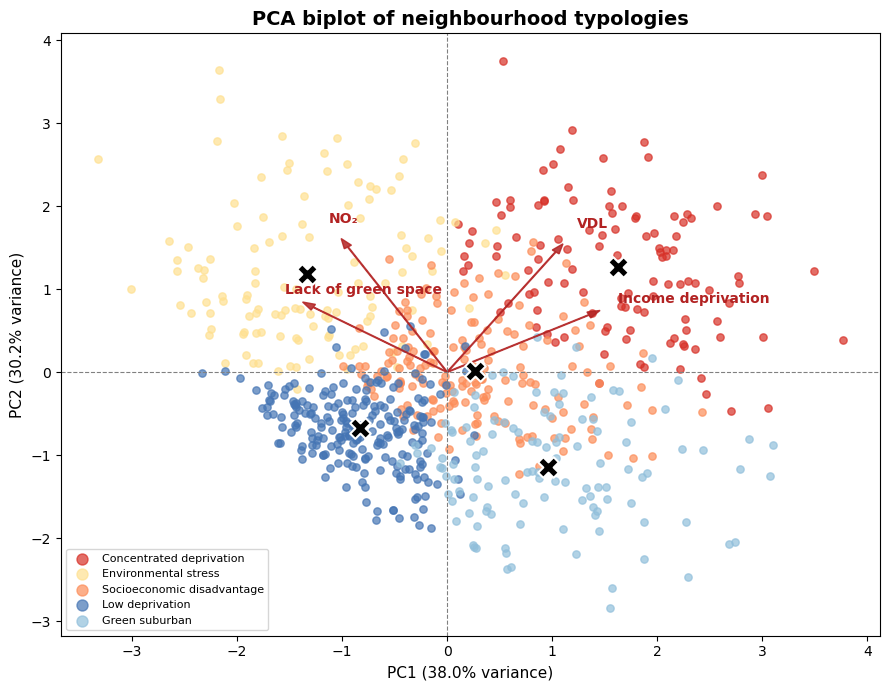

In [ ]:
# PCA biplot

fig, ax = plt.subplots(figsize=(9, 7))

for tname in type_order:
    mask = gdf['Type'] == tname
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=TYPE_COLORS[tname], s=28, alpha=0.7, label=tname)

# Cluster centroids in PCA space
centroids_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
centroids_pca['Type'] = gdf['Type'].values
cent = centroids_pca.groupby('Type').mean()
ax.scatter(cent['PC1'], cent['PC2'], marker='X', s=220,
           c='black', edgecolors='white', linewidths=1.5, zorder=5)

# Loading arrows
scale = 2.5
for i, variable in enumerate(cluster_labels):
    x = loadings.iloc[i, 0] * scale
    y = loadings.iloc[i, 1] * scale
    ax.arrow(0, 0, x, y, color='firebrick', width=0.008,
             head_width=0.08, alpha=0.85, length_includes_head=True)
    ax.text(x * 1.12, y * 1.12, variable, fontsize=10,
            fontweight='bold', color='firebrick')

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ev = pca.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('PCA biplot of neighbourhood typologies', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', frameon=True, fontsize=8, markerscale=1.5)
plt.tight_layout()
plt.show()

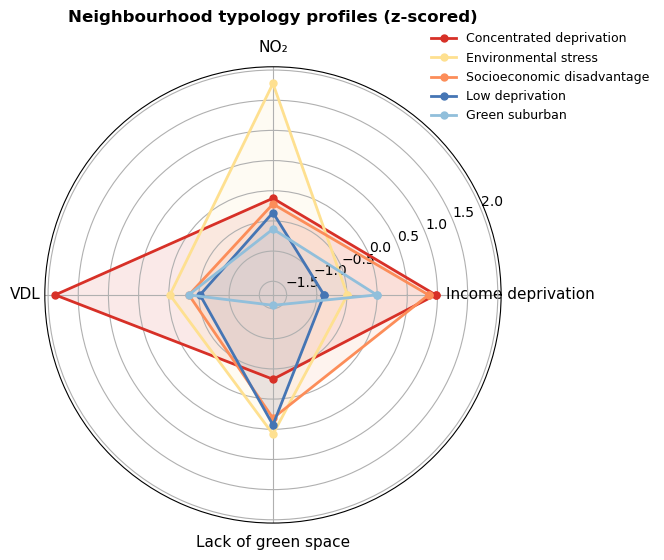

In [ ]:
# Radar chart

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(cluster_labels), endpoint=False).tolist()
angles += angles[:1]

for tname in type_order:
    cid = [c for c, n in cluster_names.items() if n == tname][0]
    vals = means_z.drop(columns='Disadvantage').loc[cid].values.tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=tname,
            color=TYPE_COLORS[tname], markersize=5)
    ax.fill(angles, vals, alpha=0.1, color=TYPE_COLORS[tname])

ax.set_thetagrids(np.degrees(angles[:-1]), cluster_labels, fontsize=11)
ax.set_title('Neighbourhood typology profiles (z-scored)', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

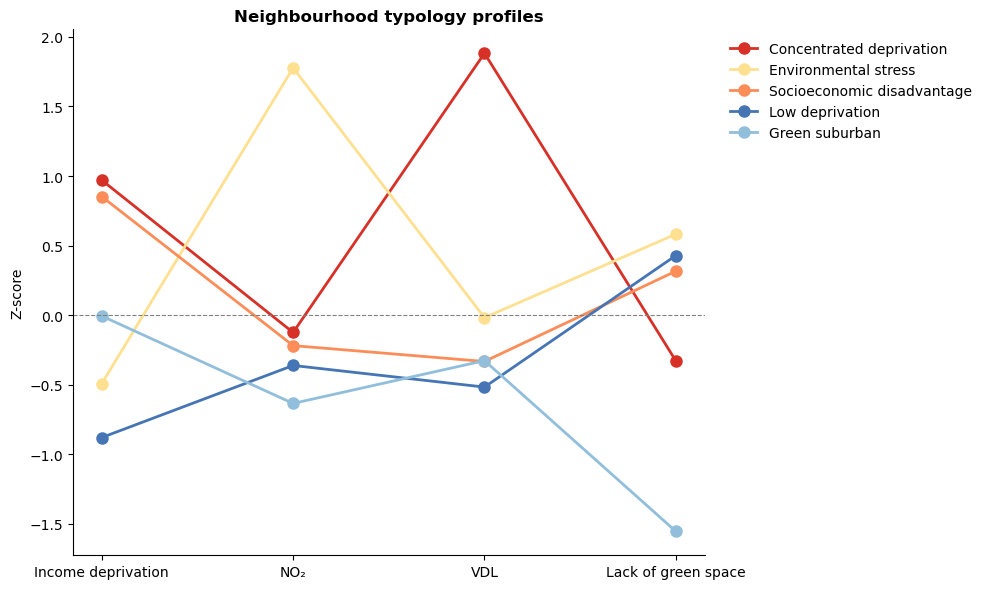

In [ ]:
# Supplement: Parallel coordinates 
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(cluster_labels))
for tname in type_order:
    cid = [c for c, n in cluster_names.items() if n == tname][0]
    vals = means_z.drop(columns='Disadvantage').loc[cid].values
    ax.plot(x, vals, 'o-', linewidth=2, label=tname,
            color=TYPE_COLORS[tname], markersize=8)
ax.set_xticks(x)
ax.set_xticklabels(cluster_labels)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_ylabel('Z-score')
ax.set_title('Neighbourhood typology profiles')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

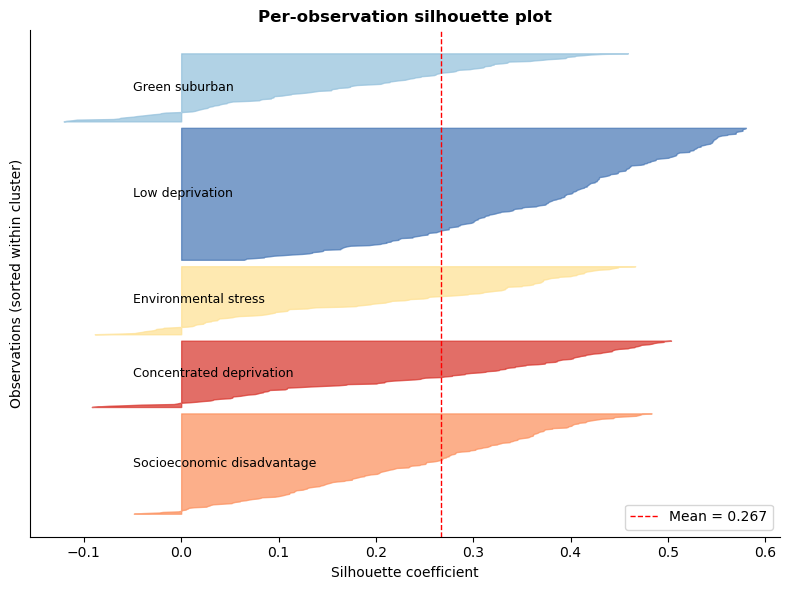

Negative silhouette observations (potentially misclassified):
  Socioeconomic disadvantage: 6/172 (3.5%)
  Concentrated deprivation: 8/114 (7.0%)
  Environmental stress: 13/117 (11.1%)
  Low deprivation: 0/226 (0.0%)
  Green suburban: 16/117 (13.7%)


In [ ]:
# Per-observation silhouette analysis

sample_sil = silhouette_samples(X_z, gdf['Cluster'].values)
avg_sil = silhouette_score(X_z, gdf['Cluster'].values)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10

for i in range(K):
    cluster_sil = sample_sil[gdf['Cluster'].values == i]
    cluster_sil.sort()
    size_i = len(cluster_sil)
    y_upper = y_lower + size_i
    tname = cluster_names[i]
    color = TYPE_COLORS.get(tname, '#888888')
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, tname, fontsize=9, va='center')
    y_lower = y_upper + 10

ax.axvline(x=avg_sil, color='red', linestyle='--', linewidth=1,
           label=f'Mean = {avg_sil:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Observations (sorted within cluster)')
ax.set_title('Per-observation silhouette plot')
ax.set_yticks([])
ax.legend(loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('Negative silhouette observations (potentially misclassified):')
for i in range(K):
    neg = (sample_sil[gdf['Cluster'].values == i] < 0).sum()
    total = (gdf['Cluster'].values == i).sum()
    pct = neg / total * 100
    print(f'  {cluster_names[i]}: {neg}/{total} ({pct:.1f}%)')

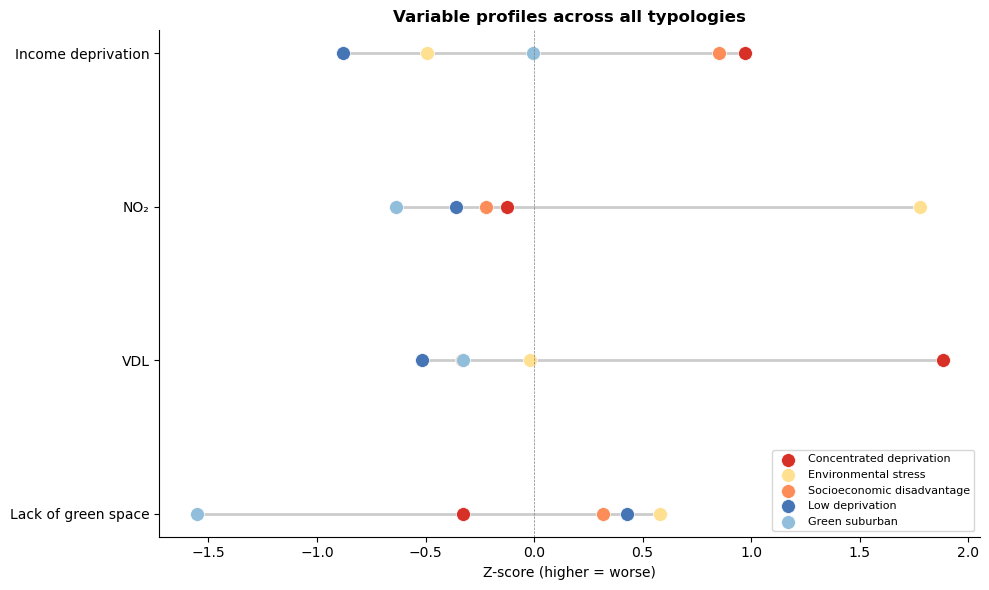

In [28]:
# Dumbbell chart

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(cluster_labels))

for tname in type_order:
    cid = [c for c, n in cluster_names.items() if n == tname][0]
    vals = means_z.drop(columns='Disadvantage').loc[cid].values
    ax.scatter(vals, y_pos, color=TYPE_COLORS[tname], s=100,
               zorder=2, label=tname, edgecolors='white', linewidth=0.5)

for i in range(len(cluster_labels)):
    all_vals = [means_z.drop(columns='Disadvantage').iloc[c, i]
                for c in range(K)]
    ax.plot([min(all_vals), max(all_vals)], [i, i],
            color='#cccccc', linewidth=2, zorder=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(cluster_labels)
ax.set_xlabel('Z-score (higher = worse)')
ax.set_title('Variable profiles across all typologies')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.legend(loc='lower right', frameon=True, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Kruskal-Wallis + effect sizes (clustering variables)

print('=== Kruskal-Wallis tests (clustering variables) ===')
print()
print(f'{"Variable":<22} {"H-statistic":>12} {"p-value":>12} {"\u03b5\u00b2":>8} {"Sig":>8}')
print('-' * 66)

for col, label in zip(cluster_cols, cluster_labels):
    groups = [gdf[gdf['Cluster'] == c][col].values for c in range(K)]
    h, p = stats.kruskal(*groups)
    epsilon2 = (h - K + 1) / (len(gdf) - K)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    print(f'{label:<22} {h:>12.2f} {p:>12.2e} {epsilon2:>8.3f} {sig:>8}')

=== Kruskal-Wallis tests (clustering variables) ===

Variable                H-statistic      p-value       ε²      Sig
------------------------------------------------------------------
Income deprivation           439.27     9.06e-94    0.587      ***
NO₂                          319.10     8.21e-68    0.425      ***
VDL                          326.19     2.42e-69    0.435      ***
Lack of green space          330.12     3.44e-70    0.440      ***


In [ ]:
# Dunn post-hoc tests (clustering variables)

for col, label in zip(cluster_cols, cluster_labels):
    print('=' * 60)
    print(label)
    dunn = sp.posthoc_dunn(
        gdf, val_col=col, group_col='Type', p_adjust='bonferroni'
    )
    dunn = dunn.loc[type_order, type_order]
    display(dunn.round(3))

Income deprivation


,Concentrated deprivation,Environmental stress,Socioeconomic disadvantage,Low deprivation,Green suburban
Concentrated deprivation,1.0,0.000,1.0,0.000,0.000
Environmental stress,0.0,1.000,0.0,0.003,0.001
Socioeconomic disadvantage,1.0,0.000,1.0,0.000,0.000
Low deprivation,0.0,0.003,0.0,1.000,0.000
Green suburban,0.0,0.001,0.0,0.000,1.000


NO₂


,Concentrated deprivation,Environmental stress,Socioeconomic disadvantage,Low deprivation,Green suburban
Concentrated deprivation,1.000,0.0,1.000,0.137,0.000
Environmental stress,0.000,1.0,0.000,0.000,0.000
Socioeconomic disadvantage,1.000,0.0,1.000,0.768,0.000
Low deprivation,0.137,0.0,0.768,1.000,0.012
Green suburban,0.000,0.0,0.000,0.012,1.000


VDL


,Concentrated deprivation,Environmental stress,Socioeconomic disadvantage,Low deprivation,Green suburban
Concentrated deprivation,1.0,0.0,0.000,0.000,0.000
Environmental stress,0.0,1.0,1.000,0.000,1.000
Socioeconomic disadvantage,0.0,1.0,1.000,0.001,1.000
Low deprivation,0.0,0.0,0.001,1.000,0.004
Green suburban,0.0,1.0,1.000,0.004,1.000


Lack of green space


,Concentrated deprivation,Environmental stress,Socioeconomic disadvantage,Low deprivation,Green suburban
Concentrated deprivation,1.0,0.000,0.000,0.000,0.0
Environmental stress,0.0,1.000,0.081,0.831,0.0
Socioeconomic disadvantage,0.0,0.081,1.000,1.000,0.0
Low deprivation,0.0,0.831,1.000,1.000,0.0
Green suburban,0.0,0.000,0.000,0.000,1.0


#### **· Spatial distribution**

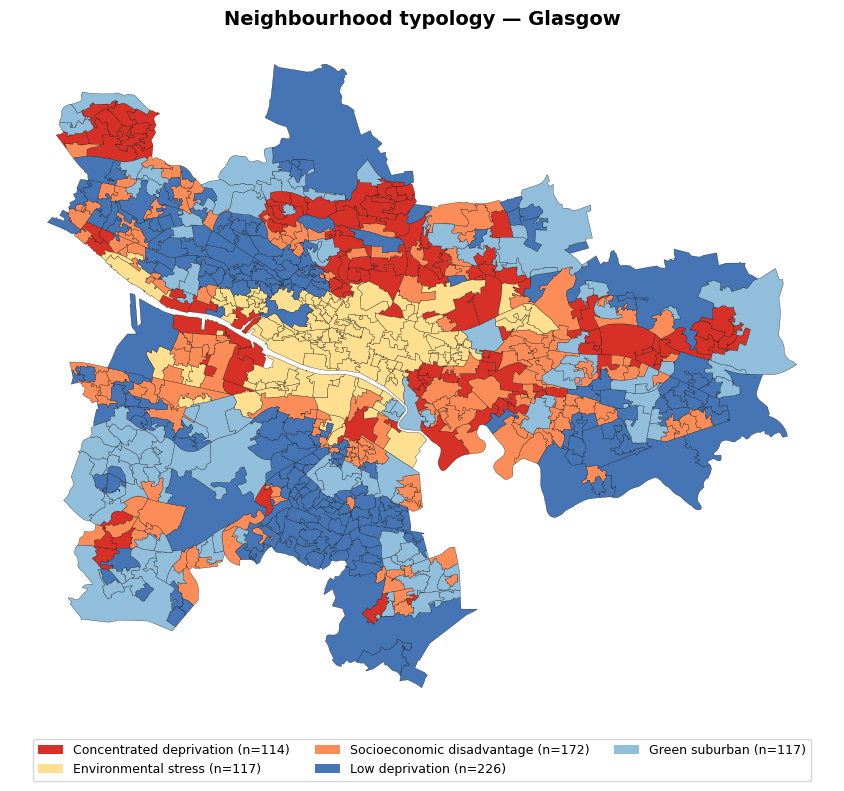

In [17]:
# Cell 16: Spatial distribution map

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

for tname in type_order:
    subset = gdf[gdf['Type'] == tname]
    if len(subset) > 0:
        subset.plot(ax=ax, color=TYPE_COLORS[tname], edgecolor='black', linewidth=0.2)

ax.set_title('Neighbourhood typology \u2014 Glasgow', fontsize=14, fontweight='bold')
ax.axis('off')

handles = [Patch(facecolor=TYPE_COLORS[t],
                 label=t + f" (n={(gdf['Type']==t).sum()})")
           for t in type_order]

ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.02),
          ncol=3, frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

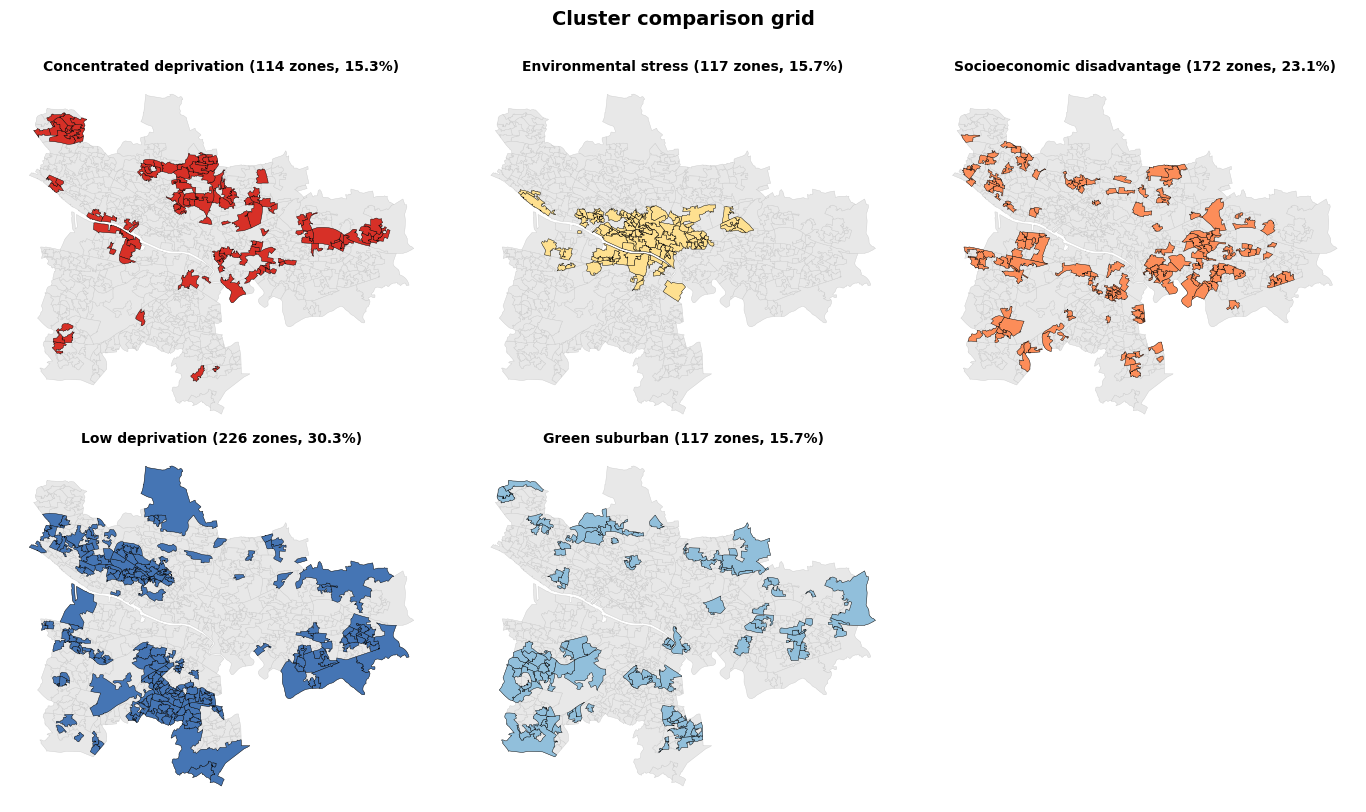

In [ ]:
# Cluster comparison grid

n_types = len(type_order)
nrows = (n_types + 2) // 3
fig, axes = plt.subplots(nrows, 3, figsize=(14, 4 * nrows))
axes = axes.flatten()

for idx, tname in enumerate(type_order):
    ax = axes[idx]
    gdf.plot(ax=ax, color='#E8E8E8', edgecolor='#CCCCCC', linewidth=0.3)
    subset = gdf[gdf['Type'] == tname]
    if len(subset) > 0:
        subset.plot(ax=ax, color=TYPE_COLORS[tname], edgecolor='black', linewidth=0.3)
    n = len(subset)
    pct = n / len(gdf) * 100
    ax.set_title(f'{tname} ({n} zones, {pct:.1f}%)', fontsize=10)
    ax.axis('off')

for idx in range(len(type_order), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Cluster comparison grid', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### **· Rubustness check**

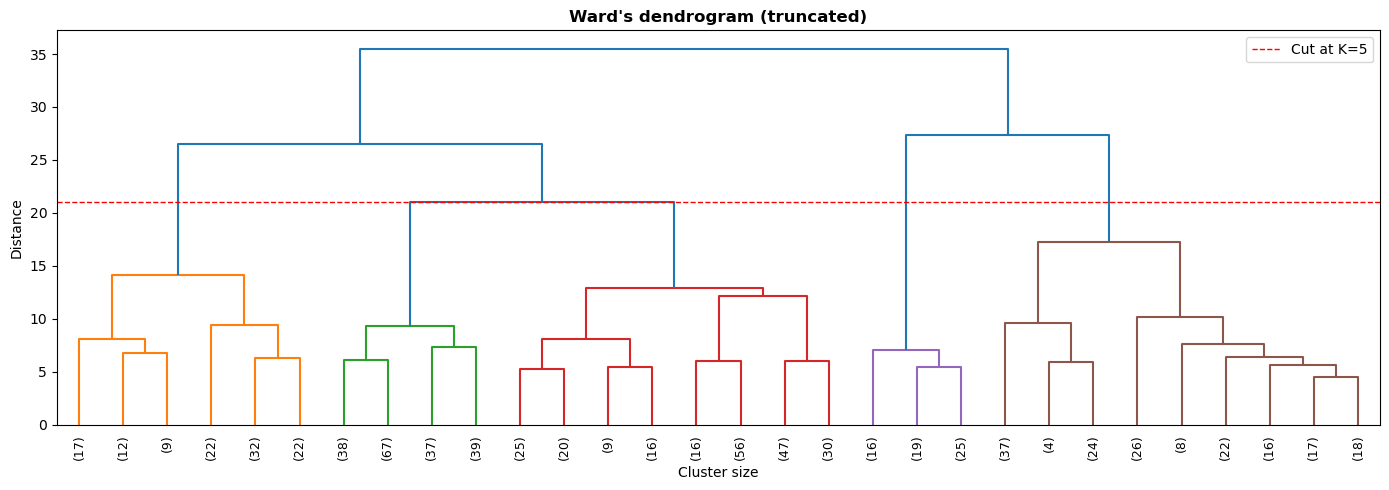

=== Robustness: K-means vs Ward ===
K-means silhouette:  0.2669
Ward silhouette:     0.1846
Agreement:           559/746 (74.9%)
Result: MODERATE agreement - core structure is stable

=== Per-type agreement (K-means vs Ward) ===
  Concentrated deprivation       60/114 (52.6%)
  Environmental stress           99/117 (84.6%)
  Socioeconomic disadvantage     126/172 (73.3%)
  Low deprivation                174/226 (77.0%)
  Green suburban                 100/117 (85.5%)


In [ ]:
# Robustness check: Ward hierarchical clustering

Z_linkage = linkage(X_z, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z_linkage, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=9, ax=ax, color_threshold=Z_linkage[-(K-1), 2])
ax.set_title("Ward's dendrogram (truncated)")
ax.set_xlabel('Cluster size')
ax.set_ylabel('Distance')
ax.axhline(y=Z_linkage[-(K-1), 2], color='red', linestyle='--', linewidth=1,
           label=f'Cut at K={K}')
ax.legend()
plt.tight_layout()
plt.show()

ward_labels = fcluster(Z_linkage, t=K, criterion='maxclust') - 1

# Best permutation match
best_match, best_perm = 0, None
for perm in permutations(range(K)):
    remapped = np.array([perm[l] for l in ward_labels])
    match = (remapped == gdf['Cluster'].values).sum()
    if match > best_match:
        best_match = match
        best_perm = perm

consistency = best_match / len(gdf) * 100
ward_sil = silhouette_score(X_z, ward_labels)
km_sil = silhouette_score(X_z, gdf['Cluster'])

print('=== Robustness: K-means vs Ward ===')
print(f'K-means silhouette:  {km_sil:.4f}')
print(f'Ward silhouette:     {ward_sil:.4f}')
print(f'Agreement:           {best_match}/{len(gdf)} ({consistency:.1f}%)')

if consistency >= 85:
    print('Result: Typology is ROBUST (>=85% agreement)')
elif consistency >= 70:
    print('Result: MODERATE agreement - core structure is stable')
else:
    print('Result: LOW agreement - interpret with caution')

# Per-type stability
print()
print('=== Per-type agreement (K-means vs Ward) ===')
ward_remapped = np.array([best_perm[l] for l in ward_labels])
for c in sorted_clusters.index:
    km_mask = gdf['Cluster'].values == c
    match_c = (ward_remapped[km_mask] == c).sum()
    total_c = km_mask.sum()
    pct_c = match_c / total_c * 100
    print(f'  {cluster_names[c]:<30} {match_c}/{total_c} ({pct_c:.1f}%)')

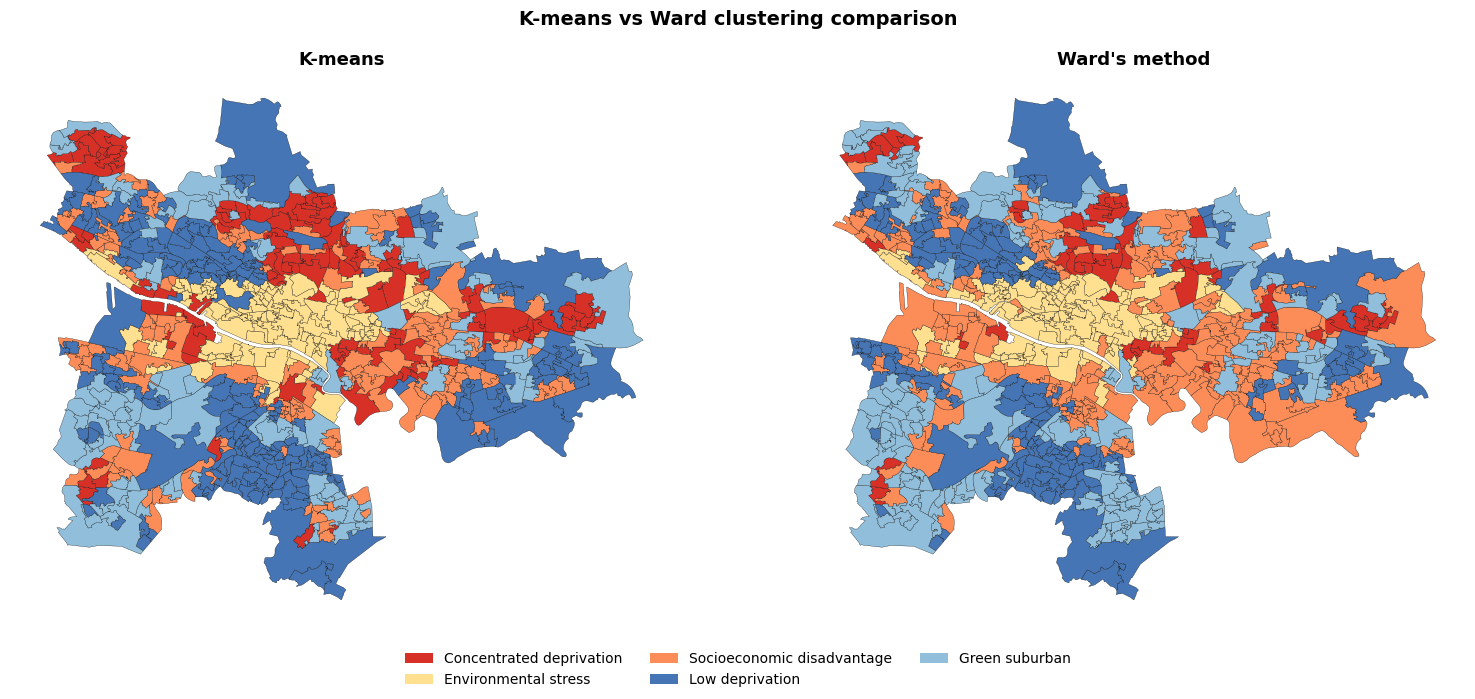

In [ ]:
# Ward vs K-means spatial comparison

gdf['Ward_Type'] = pd.Series(ward_remapped).map(cluster_names).values

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, col, title in zip(axes, ['Type', 'Ward_Type'], ['K-means', "Ward's method"]):
    for tname in type_order:
        subset = gdf[gdf[col] == tname]
        if len(subset) > 0:
            subset.plot(ax=ax, color=TYPE_COLORS[tname], edgecolor='black',
                        linewidth=0.2, label=tname)
    ax.set_title(title, fontsize=13)
    ax.axis('off')

handles = [Patch(facecolor=TYPE_COLORS[t], label=t) for t in type_order]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False, fontsize=10)
plt.suptitle('K-means vs Ward clustering comparison', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()

In [ ]:
# Sensitivity: Z-score vs Min-Max

scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X_raw)

km_mm = KMeans(n_clusters=K, init='k-means++', n_init=50, random_state=42)
labels_mm = km_mm.fit_predict(X_mm)

best_match_mm, best_perm_mm = 0, None
for perm in permutations(range(K)):
    remapped = np.array([perm[l] for l in labels_mm])
    match = (remapped == gdf['Cluster'].values).sum()
    if match > best_match_mm:
        best_match_mm = match
        best_perm_mm = perm

mm_consistency = best_match_mm / len(gdf) * 100
mm_sil = silhouette_score(X_mm, labels_mm)

print(f'Z-score silhouette:  {silhouette_score(X_z, gdf["Cluster"]):.4f}')
print(f'Min-Max silhouette:  {mm_sil:.4f}')
print(f'Agreement: {best_match_mm}/{len(gdf)} ({mm_consistency:.1f}%)')

if mm_consistency >= 85:
    print('Result: ROBUST to standardisation choice')
elif mm_consistency >= 70:
    print('Result: MODERATE sensitivity')
else:
    print('Result: SENSITIVE - Z-score reported as primary')

c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Z-score silhouette:  0.2669
Min-Max silhouette:  0.2769
Agreement: 686/746 (92.0%)
Result: ROBUST to standardisation choice


In [ ]:
# ARI stability test

aris = []
reference = None
for seed in range(50):
    km = KMeans(n_clusters=K, init='k-means++', n_init=50, random_state=seed)
    labels = km.fit_predict(X_z)
    if reference is None:
        reference = labels
    else:
        aris.append(adjusted_rand_score(reference, labels))

print('=' * 60)
print('Adjusted Rand Index (K-means initialisation stability)')
print('=' * 60)
print(f'Mean ARI  = {np.mean(aris):.4f}')
print(f'Std ARI   = {np.std(aris):.4f}')
print(f'Min ARI   = {np.min(aris):.4f}')
if np.mean(aris) > 0.95:
    print('Result: HIGHLY STABLE across initialisations')

c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-pa

Adjusted Rand Index (K-means initialisation stability)
Mean ARI  = 0.9914
Std ARI   = 0.0127
Min ARI   = 0.9205
Result: HIGHLY STABLE across initialisations


#### **· External Validation: Health Burden**

HlthCIF was **not used** in clustering. If the income-environmental typology also distinguishes health outcomes, this provides independent evidence that the typology captures meaningful neighbourhood-level inequality.

EXTERNAL VALIDATION: Health burden (HlthCIF) by typology

Kruskal-Wallis H = 407.15,  p = 7.93e-87
Effect size ε²  = 0.544
Significance: ***

Type                               N     Mean   Median      Std
-----------------------------------------------------------------
Concentrated deprivation         114    217.2    225.0     51.3
Environmental stress             117    114.7    110.0     62.6
Socioeconomic disadvantage       172    210.6    205.0     42.7
Low deprivation                  226     91.2     85.0     40.7
Green suburban                   117    156.6    160.0     59.5


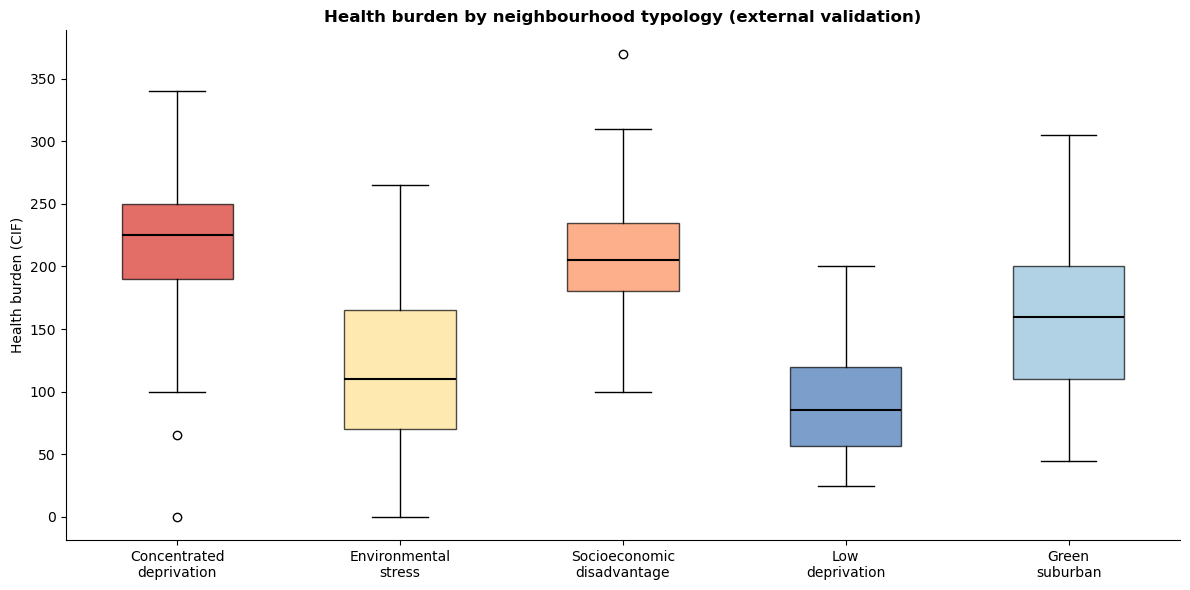

In [ ]:
# External validation -- Health burden by typology

# Kruskal-Wallis
groups_h = [gdf[gdf['Type'] == t]['HlthCIF'].values for t in type_order]
h_kw, p_kw = stats.kruskal(*groups_h)
epsilon2_h = (h_kw - K + 1) / (len(gdf) - K)

print('=' * 66)
print('EXTERNAL VALIDATION: Health burden (HlthCIF) by typology')
print('=' * 66)
print()
print(f'Kruskal-Wallis H = {h_kw:.2f},  p = {p_kw:.2e}')
print(f'Effect size \u03b5\u00b2  = {epsilon2_h:.3f}')
sig = '***' if p_kw < 0.001 else ('**' if p_kw < 0.01 else ('*' if p_kw < 0.05 else 'n.s.'))
print(f'Significance: {sig}')

# Descriptive statistics
print()
print(f'{"Type":<30} {"N":>5} {"Mean":>8} {"Median":>8} {"Std":>8}')
print('-' * 65)
for t in type_order:
    s = gdf[gdf['Type'] == t]['HlthCIF']
    print(f'{t:<30} {len(s):>5} {s.mean():>8.1f} {s.median():>8.1f} {s.std():>8.1f}')

# Boxplot
fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(groups_h,
                tick_labels=[t.replace(' ', '\n') for t in type_order],
                patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=1.5))

for i, tname in enumerate(type_order):
    bp['boxes'][i].set_facecolor(TYPE_COLORS[tname])
    bp['boxes'][i].set_alpha(0.7)

ax.set_ylabel('Health burden (CIF)')
ax.set_title('Health burden by neighbourhood typology (external validation)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# Dunn post-hoc for health burden

print('=== Dunn post-hoc: Health burden (Bonferroni-adjusted) ===')
dunn_h = sp.posthoc_dunn(
    gdf, val_col='HlthCIF', group_col='Type', p_adjust='bonferroni'
)
dunn_h = dunn_h.loc[type_order, type_order]
display(dunn_h.round(3))

=== Dunn post-hoc: Health burden (Bonferroni-adjusted) ===


,Concentrated deprivation,Environmental stress,Socioeconomic disadvantage,Low deprivation,Green suburban
Concentrated deprivation,1.0,0.000,1.0,0.000,0.0
Environmental stress,0.0,1.000,0.0,0.016,0.0
Socioeconomic disadvantage,1.0,0.000,1.0,0.000,0.0
Low deprivation,0.0,0.016,0.0,1.000,0.0
Green suburban,0.0,0.000,0.0,0.000,1.0


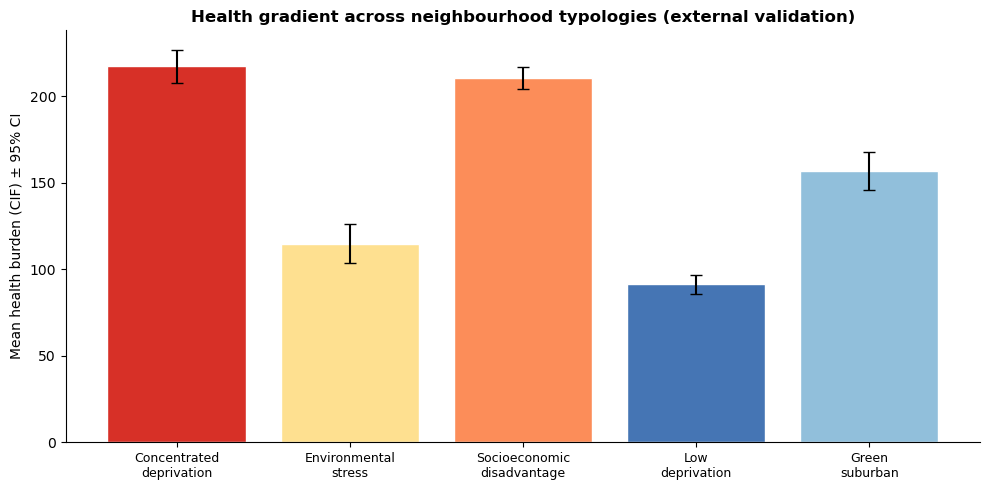

In [ ]:
# Health gradient bar chart

fig, ax = plt.subplots(figsize=(10, 5))

means_health = [gdf[gdf['Type'] == t]['HlthCIF'].mean() for t in type_order]
ci_health = [1.96 * gdf[gdf['Type'] == t]['HlthCIF'].std() /
             np.sqrt((gdf['Type'] == t).sum()) for t in type_order]

bars = ax.bar(range(len(type_order)), means_health, yerr=ci_health,
              color=[TYPE_COLORS[t] for t in type_order],
              edgecolor='white', capsize=4)

ax.set_xticks(range(len(type_order)))
ax.set_xticklabels([t.replace(' ', '\n') for t in type_order], fontsize=9)
ax.set_ylabel('Mean health burden (CIF) \u00b1 95% CI')
ax.set_title('Health gradient across neighbourhood typologies (external validation)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

#### **· Temporal Analysis--Income deprivation**

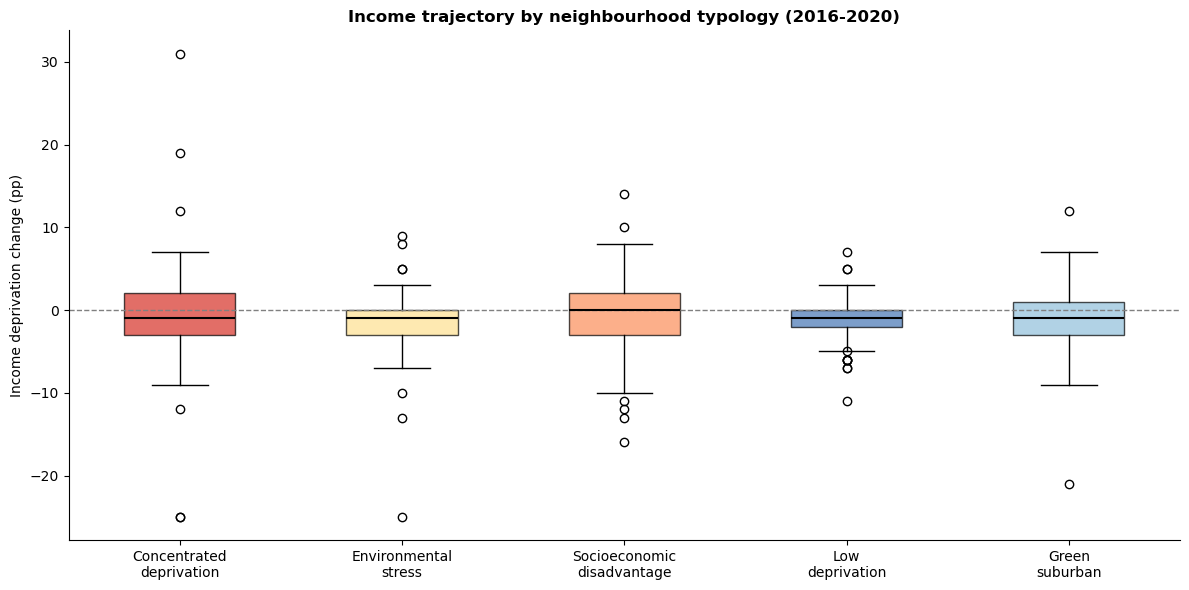

Kruskal-Wallis: H = 8.05, p = 8.9682e-02

Type                               N     Mean   Median
-------------------------------------------------------
Concentrated deprivation         114    -0.82    -1.00
Environmental stress             117    -1.65    -1.00
Socioeconomic disadvantage       172    -0.60    +0.00
Low deprivation                  226    -1.00    -1.00
Green suburban                   117    -0.88    -1.00


In [ ]:
# Income trajectory (2016-2020)

fig, ax = plt.subplots(figsize=(12, 6))

bp_data = [gdf[gdf['Type'] == t]['Inc_Change'].values for t in type_order]
bp = ax.boxplot(bp_data,
                tick_labels=[t.replace(' ', '\n') for t in type_order],
                patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=1.5))

for i, tname in enumerate(type_order):
    bp['boxes'][i].set_facecolor(TYPE_COLORS[tname])
    bp['boxes'][i].set_alpha(0.7)

ax.axhline(0, color='grey', linestyle='--', linewidth=1)
ax.set_ylabel('Income deprivation change (pp)')
ax.set_title('Income trajectory by neighbourhood typology (2016-2020)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Kruskal-Wallis
h, p = stats.kruskal(*bp_data)
print(f'Kruskal-Wallis: H = {h:.2f}, p = {p:.4e}')
print()
print(f'{"Type":<30} {"N":>5} {"Mean":>8} {"Median":>8}')
print('-' * 55)
for t in type_order:
    s = gdf[gdf['Type'] == t]['Inc_Change']
    print(f'{t:<30} {len(s):>5} {s.mean():>+8.2f} {s.median():>+8.2f}')

#### **· Final Summary**

In [ ]:
# Final summary

km_sil = silhouette_score(X_z, gdf['Cluster'])

print('=' * 80)
print('NEIGHBOURHOOD TYPOLOGY SUMMARY')
print('=' * 80)
print()

# Header
hdr = f'{"Type":<30} {"N":>5}'
for lab in cluster_labels:
    hdr += f' {lab[:10]:>10}'
hdr += f' {"HlthCIF":>10}'
print(hdr)
print('-' * 80)

for tname in type_order:
    subset = gdf[gdf['Type'] == tname]
    row = f'{tname:<30} {len(subset):>5}'
    for col in cluster_cols:
        row += f' {subset[col].mean():>10.2f}'
    row += f' {subset["HlthCIF"].mean():>10.1f}'
    print(row)

print()
print(f'Clustering: K-means (K={K}, n_init=50)')
cl_str = ' + '.join(cluster_labels)
print(f'Clustering variables: {len(cluster_cols)} ({cl_str})')
print('External validation:  HlthCIF (Health burden)')
print(f'Silhouette score:     {km_sil:.4f}')
print(f'Ward agreement:       {consistency:.1f}%')
print(f'Min-Max agreement:    {mm_consistency:.1f}%')
print(f'Mean ARI:             {np.mean(aris):.4f}')

groups_h = [gdf[gdf['Type'] == t]['HlthCIF'].values for t in type_order]
h_kw, p_kw = stats.kruskal(*groups_h)
val_str = 'SIGNIFICANT' if p_kw < 0.05 else 'NOT significant'
print(f'Health validation:    KW H={h_kw:.1f}, p={p_kw:.2e} => {val_str}')

NEIGHBOURHOOD TYPOLOGY SUMMARY

Type                               N Income dep        NO₂        VDL Lack of gr    HlthCIF
--------------------------------------------------------------------------------
Concentrated deprivation         114      31.64      13.42       0.64       0.76      217.2
Environmental stress             117      13.78      20.07       0.17       0.86      114.7
Socioeconomic disadvantage       172      30.20      13.09       0.09       0.83      210.6
Low deprivation                  226       9.05      12.59       0.04       0.84       91.2
Green suburban                   117      19.72      11.63       0.09       0.63      156.6

Clustering: K-means (K=5, n_init=50)
Clustering variables: 4 (Income deprivation + NO₂ + VDL + Lack of green space)
External validation:  HlthCIF (Health burden)
Silhouette score:     0.2669
Ward agreement:       74.9%
Min-Max agreement:    92.0%
Mean ARI:             0.9914
Health validation:    KW H=407.2, p=7.93e-87 => SIGNIFICAN

In [1]:
import subprocess
subprocess.run(['jupyter', 'nbconvert', '--to', 'html', 'Typological_Analysis_PlanB.ipynb'])

CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', 'Typological_Analysis_PlanB.ipynb'], returncode=0)